In [18]:
%pip install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import os
import json
import numpy as np

In [2]:
def parse_result_as_df_recommended(result_file):
    with open(result_file, 'r') as f:
        lines = f.readlines()
    json_data = json.loads(('').join(lines))
    
    # Handle evaluationResult array by extracting comprehensive statistics
    if 'evaluationResult' in json_data and isinstance(json_data['evaluationResult'], list):
        eval_results = json_data['evaluationResult']
        
        # Basic statistics
        json_data['evaluationResult_count'] = len(eval_results)

        # Exact matching statistics
        exact_matches = [item for item in eval_results if item.get('doesMatchExactly', False)]
        json_data['evaluationResult_exact_matches'] = len(exact_matches) > 0
        # json_data['evaluationResult_exact_rate'] = len(exact_matches) / len(eval_results) if eval_results else 0
        
        # Syntactic matching statistics
        syntactic_matches = [item for item in eval_results if item.get('doesMatchSyntactically', False)]
        json_data['evaluationResult_syntactic_matches'] = len(syntactic_matches) > 0
        # json_data['evaluationResult_syntactic_rate'] = len(syntactic_matches) / len(eval_results) if eval_results else 0
        
        # Semantic matching statistics
        semantic_matches = [item for item in eval_results if item.get('doesMatchSemantically', False)]
        json_data['evaluationResult_semantic_matches'] = len(semantic_matches) > 0
        json_data['evaluationResult_semantic_match_count'] = len(semantic_matches)
        # json_data['evaluationResult_semantic_rate'] = len(semantic_matches) / len(eval_results) if eval_results else 0
        
        # # Top suggestions
        # json_data['evaluationResult_top_suggestion'] = eval_results[0]['suggestion'] if eval_results else None
        # json_data['evaluationResult_top_rank'] = eval_results[0]['rank'] if eval_results else None
        
        # # Average rank of matches
        # if syntactic_matches:
        #     json_data['evaluationResult_avg_syntactic_rank'] = np.mean([item['rank'] for item in syntactic_matches])
        # else:
        #     json_data['evaluationResult_avg_syntactic_rank'] = None
            
        # Remove the original array to avoid DataFrame creation issues
        del json_data['evaluationResult']

        # Delete any key that starts with 'suggestionIn' to avoid redundancy
        keys_to_delete = [key for key in json_data.keys() if key.startswith('suggestionIn')]
        for key in keys_to_delete:
            del json_data[key]
    
    # Handle any other arrays in similar fashion
    for key, value in list(json_data.items()):
        if isinstance(value, list) and key != 'evaluationResult':  # Handle other potential arrays
            json_data[f'{key}_array_length'] = len(value)
            json_data[f'{key}_as_string'] = json.dumps(value)  # Keep as JSON string if needed
            del json_data[key]  # Remove original array
    
    df = pd.DataFrame(json_data, index=[0])
    return df

In [3]:
# Updated data loading code with proper JSON array handling
GENERATOR_TEST_RESULT_DIR = '../test-results/generator/multi_term/'
FORMULA_TEST_RESULT_DIR = '../test-results/formula/multi_term/'

generator_results_df = pd.DataFrame()
formula_results_df = pd.DataFrame()

print("Loading generator results...")
for root, subdirs, files in os.walk(GENERATOR_TEST_RESULT_DIR):
    for file in files:
        if file.endswith('.result.json'):
            try:
                df = parse_result_as_df_recommended(os.path.join(root, file))
                generator_results_df = pd.concat([generator_results_df, df], axis=0, ignore_index=True)
            except Exception as e:
                print(f"Error processing {file}: {e}")

print(f"Generator results loaded: {len(generator_results_df)} records")

print("Loading formula results...")
for root, subdirs, files in os.walk(FORMULA_TEST_RESULT_DIR):
    for file in files:
        if file.endswith('.result.json'):
            try:
                df = parse_result_as_df_recommended(os.path.join(root, file))
                formula_results_df = pd.concat([formula_results_df, df], axis=0, ignore_index=True)
            except Exception as e:
                print(f"Error processing {file}: {e}")

print(f"Formula results loaded: {len(formula_results_df)} records")

Loading generator results...
Generator results loaded: 625 records
Loading formula results...
Formula results loaded: 625 records


In [4]:
generator_results_df

,modelName,filename,offset,term,line,character,incompletionLine,completionList,completionGenerated,suggestionExists,expectedCompletionWord,expectedCompletionLine,elapsedTimeInMs,evaluationResult_count,evaluationResult_exact_matches,evaluationResult_syntactic_matches,evaluationResult_semantic_matches,evaluationResult_semantic_match_count
0,class-diagram,completion/class-diagram-complete.als,343,-,19,17,all c: Class -,"((*ext)-ext), ((^ext)-ext), ((ext.Class).ext),...",True,True,Object,Object | c in Object.^~ext,7.668000,50,True,True,False,0
1,class-diagram,completion/class-diagram-complete.als,136,.,9,12,no Object.,"((*ext)-ext), ((^ext)-ext), ((ext.Class).ext),...",True,True,ext,ext,7.629042,50,True,True,True,26
2,class-diagram,completion/class-diagram-sig.als,56,extends,5,23,one sig Object extends,"((*ext)-ext), ((^ext)-ext), ((ext.Class).ext),...",True,True,Class,Class {},179.777958,49,True,True,False,0
3,class-diagram,completion/class-diagram-complete.als,357,in,19,31,all c: Class - Object | c in,"((*ext)-ext), ((*ext).c), ((^ext)-ext), ((^ext...",True,True,Object,Object.^~ext,5.938750,92,True,False,True,66
4,class-diagram,completion/class-diagram-complete.als,364,.,19,38,all c: Class - Object | c in Object.,"((*ext)-ext), ((*ext).c), ((^ext)-ext), ((^ext...",True,False,^~ext,^~ext,6.767583,92,False,False,True,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,classroom-rl,completion/classroom-rl-complete.als,756,.,61,34,all x : Teacher | some x.Teaches.,"((*Tutors)-Tutors), ((*Tutors).Student), ((*Tu...",True,True,Groups,Groups,9.612458,193,True,False,True,63
621,classroom-rl,completion/classroom-rl-complete.als,315,+,29,21,Person in Student +,"((*Tutors)-Tutors), ((*Tutors).Student), ((*Tu...",True,True,Teacher,Teacher,8.894958,184,True,True,True,121
622,classroom-rl,completion/classroom-rl-complete.als,954,&,73,35,all p : Person | some ^Tutors.p &,"((*Tutors)-Tutors), ((*Tutors).p), ((*Tutors)....",True,True,Teacher,Teacher,9.826500,293,True,False,True,229
623,classroom-rl,completion/classroom-rl-complete.als,889,.,69,63,"all p : Person, c : Class | some p.(c.Groups) ...","((*Tutors)-Tutors), ((*Tutors).p), ((*Tutors)....",True,True,c,c in Tutors.p,10.626792,336,True,False,False,0


In [5]:
formula_results_df

,modelName,filename,offset,term,line,character,incompletionLine,completionList,completionGenerated,suggestionExists,expectedCompletionWord,expectedCompletionLine,elapsedTimeInMs,evaluationResult_count,evaluationResult_exact_matches,evaluationResult_syntactic_matches,evaluationResult_semantic_matches,evaluationResult_semantic_match_count
0,class-diagram,completion/class-diagram-complete.als,343,-,19,17,all c: Class -,"Class, Object, Int, String, none, univ",True,True,Object,Object | c in Object.^~ext,33.884333,6,True,True,False,0
1,class-diagram,completion/class-diagram-complete.als,136,.,9,12,no Object.,"*ext.Class, *ext.Object, ^ext.Class, ^ext.Obje...",True,True,ext,ext,9.218458,16,True,True,True,4
2,class-diagram,completion/class-diagram-sig.als,56,extends,5,23,one sig Object extends,"Class, Int, String, none, univ",True,True,Class,Class {},8.456916,5,True,True,False,0
3,class-diagram,completion/class-diagram-complete.als,357,in,19,31,all c: Class - Object | c in,"*ext.c, *ext.c.*ext, *ext.c.^ext, *ext.c.ext, ...",True,True,Object,Object.^~ext,38.805125,103,True,False,True,103
4,class-diagram,completion/class-diagram-complete.als,364,.,19,38,all c: Class - Object | c in Object.,"*ext.c, ^ext.c, ext.c, ~ext.c, *ext.Class, *ex...",True,False,^~ext,^~ext,6.538959,20,False,False,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
620,classroom-rl,completion/classroom-rl-complete.als,756,.,61,34,all x : Teacher | some x.Teaches.,"~Teaches.x, Groups.Group, ~Teaches.Person, ~Te...",True,True,Groups,Groups,201.982000,13,True,False,True,8
621,classroom-rl,completion/classroom-rl-complete.als,315,+,29,21,Person in Student +,"*Tutors.Person, *Tutors.Person.*Tutors, *Tutor...",True,True,Teacher,Teacher,96.365125,160,True,True,True,160
622,classroom-rl,completion/classroom-rl-complete.als,954,&,73,35,all p : Person | some ^Tutors.p &,"*Tutors.p, *Tutors.p.*Tutors, *Tutors.p.Tutors...",True,True,Teacher,Teacher,131.281000,189,True,False,True,189
623,classroom-rl,completion/classroom-rl-complete.als,889,.,69,63,"all p : Person, c : Class | some p.(c.Groups) ...","c, c.Groups, c.~Teaches, Class, Class.Groups, ...",True,True,c,c in Tutors.p,7.361375,17,True,False,False,0


In [6]:
# results_df['suggestion_state'] = results_df.apply(lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)
generator_results_df['suggestion_state'] = generator_results_df.apply(
    lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)

formula_results_df['suggestion_state'] = formula_results_df.apply(
    lambda row: 'no-suggestion' if not row['completionGenerated'] else row['suggestionExists'], axis=1)

In [7]:
import matplotlib.pyplot as plt

In [8]:
# Configure notebook display for wider figures
from IPython.display import HTML, display

# Set CSS to make figures use more width
display(HTML("""
<style>
    .output_png {
        display: block;
        margin: 0 auto;
        max-width: 100% !important;
        width: 100% !important;
    }
    .jp-OutputArea-output {
        overflow-x: auto;
    }
</style>
"""))

# Configure matplotlib backend for better notebook integration
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 0

In [9]:
# avg_time_per_model = results_df.groupby('modelName')['elapsedTimeInMs'].mean()
# median_time_per_model = results_df.groupby('modelName')['elapsedTimeInMs'].median()
# p99_time_per_model = results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
# suggestion_count_per_model = results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)

generator_avg_time_per_model = generator_results_df.groupby('modelName')['elapsedTimeInMs'].mean()
generator_median_time_per_model = generator_results_df.groupby('modelName')['elapsedTimeInMs'].median()
generator_p99_time_per_model = generator_results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
generator_suggestion_count_per_model = generator_results_df.groupby('modelName')['evaluationResult_count'].mean()
generator_suggestion_state_count_per_model = generator_results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)
generator_suggestion_state_count = generator_suggestion_state_count_per_model.sum()

formula_avg_time_per_model = formula_results_df.groupby('modelName')['elapsedTimeInMs'].mean()
formula_median_time_per_model = formula_results_df.groupby('modelName')['elapsedTimeInMs'].median()
formula_p99_time_per_model = formula_results_df.groupby('modelName')['elapsedTimeInMs'].quantile(0.99)
formula_suggestion_count_per_model = formula_results_df.groupby('modelName')['evaluationResult_count'].mean()
formula_suggestion_state_count_per_model = formula_results_df.groupby('modelName')['suggestion_state'].value_counts().unstack().fillna(0)
formula_suggestion_state_count = formula_suggestion_state_count_per_model.sum()

# print("Generator suggestion counts per model:")
# print(generator_suggestion_state_count_per_model)

# print("\nFormula suggestion counts per model:")
# print(formula_suggestion_state_count_per_model)

print("\nOverall generator suggestion state counts:")
print(generator_suggestion_state_count)

print("\nOverall formula suggestion state counts:")
print(formula_suggestion_state_count)


Overall generator suggestion state counts:
suggestion_state
False             69.0
True             554.0
no-suggestion      2.0
dtype: float64

Overall formula suggestion state counts:
suggestion_state
False             62.0
True             533.0
no-suggestion     30.0
dtype: float64


In [10]:
generator_suggestion_state_count_per_model

suggestion_state,False,True,no-suggestion
modelName,,,
array,0.0,9.0,0.0
bempl,0.0,8.0,0.0
binary-tree,2.0,7.0,0.0
c-tree,3.0,6.0,0.0
class-diagram,2.0,4.0,0.0
classroom,3.0,27.0,0.0
classroom-fol,4.0,34.0,0.0
classroom-rl,2.0,28.0,0.0
courses-v1,7.0,48.0,0.0


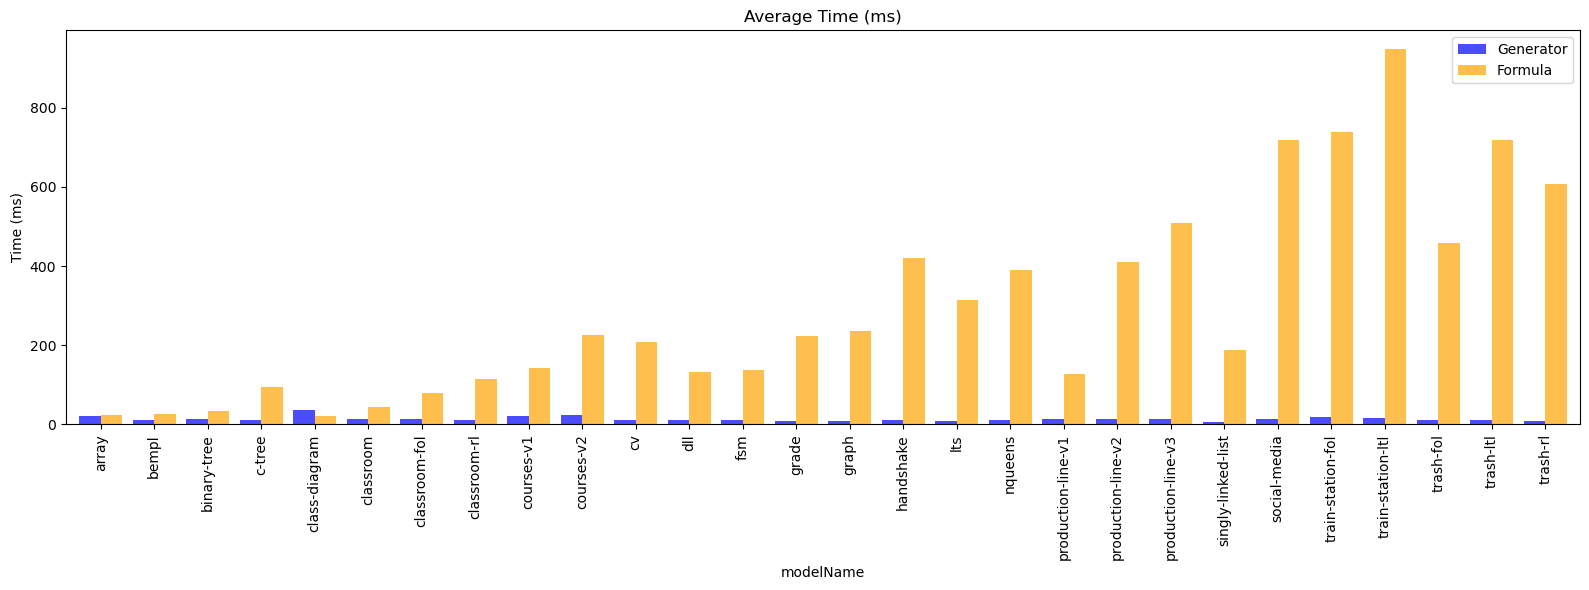

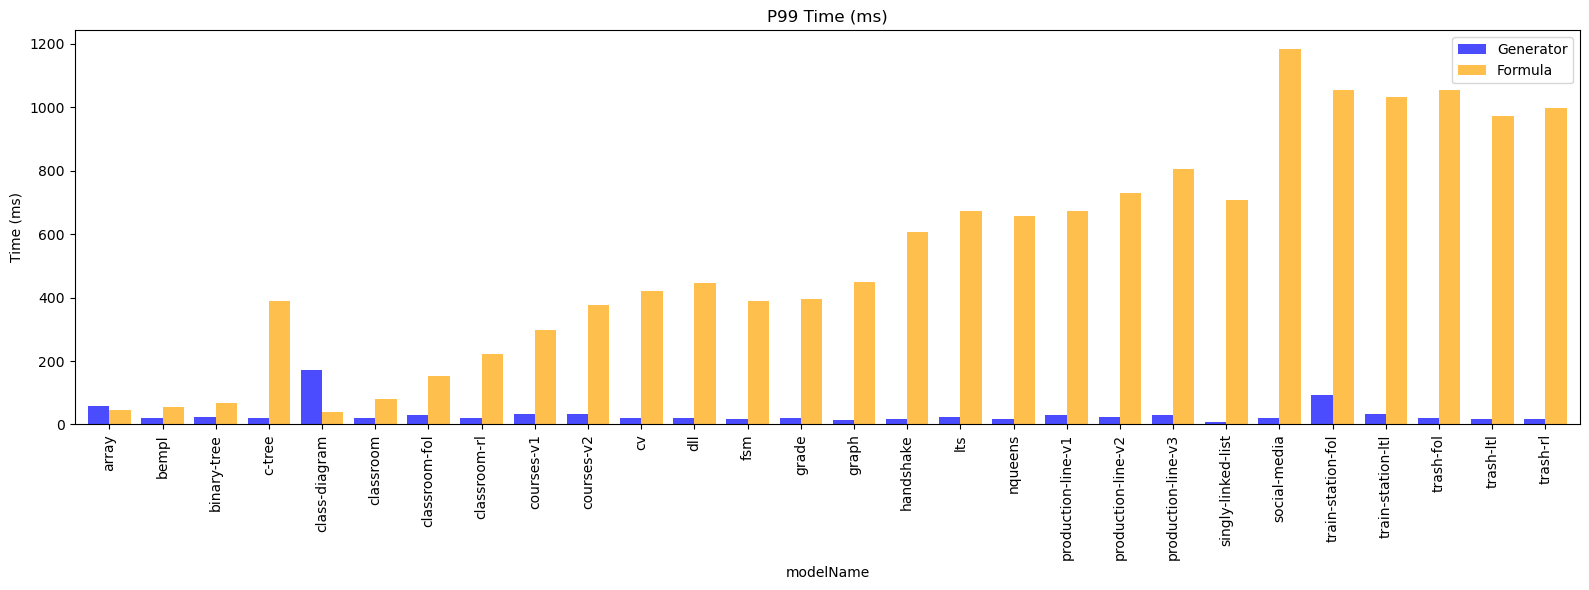

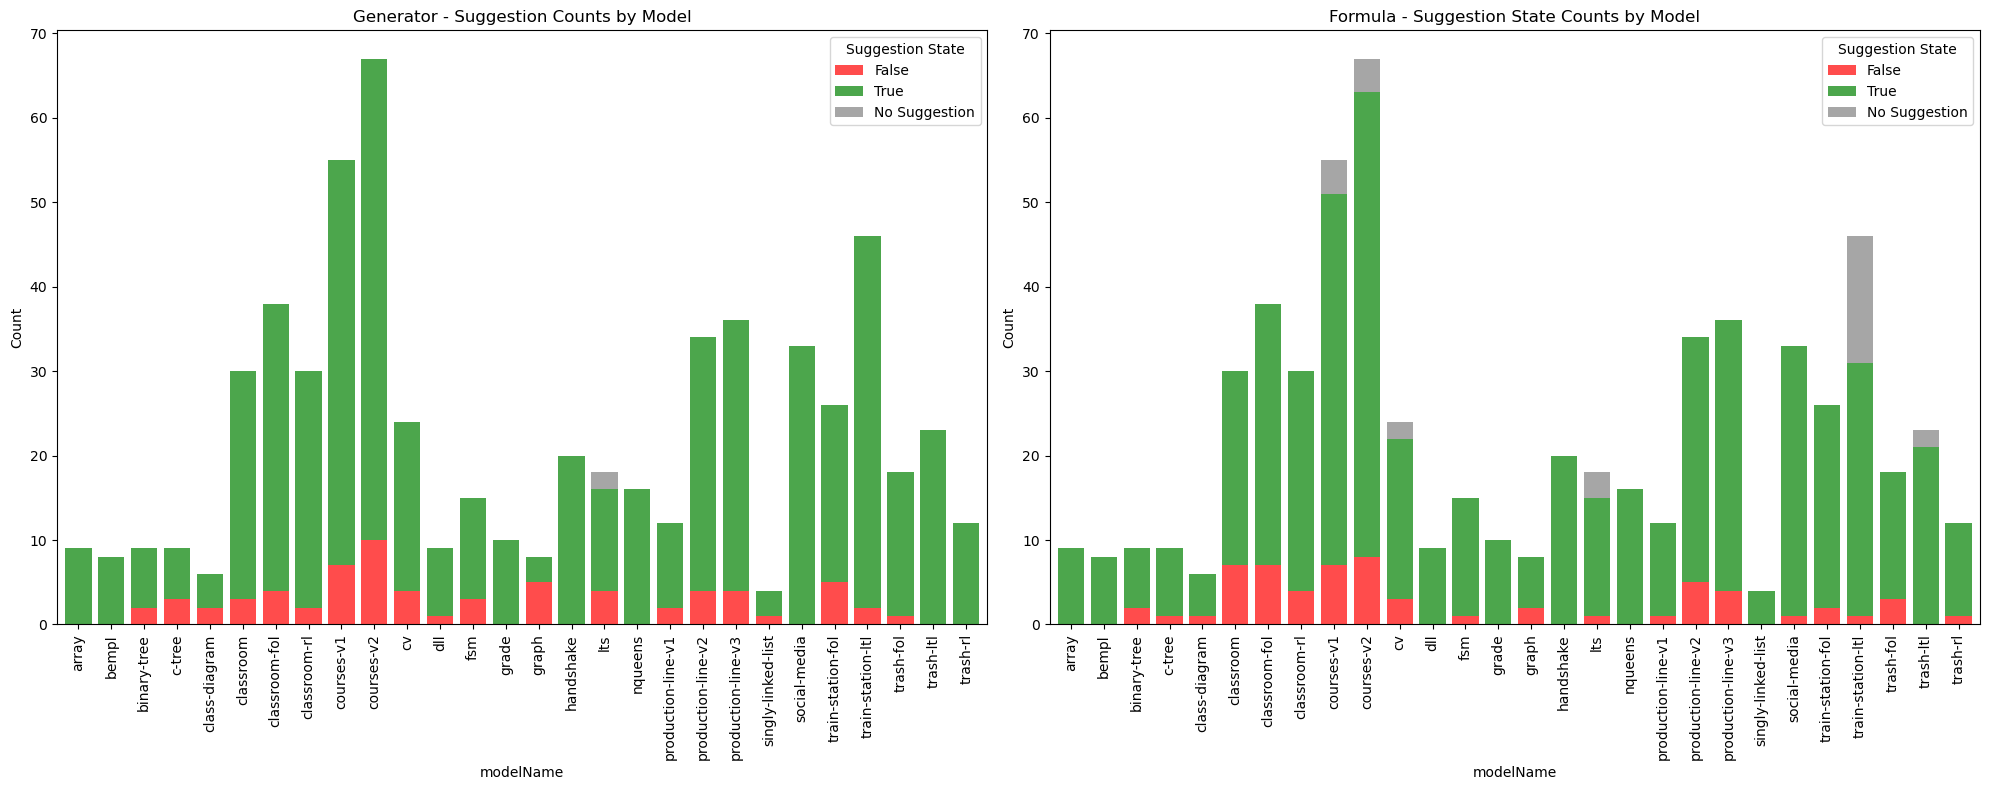

<Figure size 1600x600 with 0 Axes>

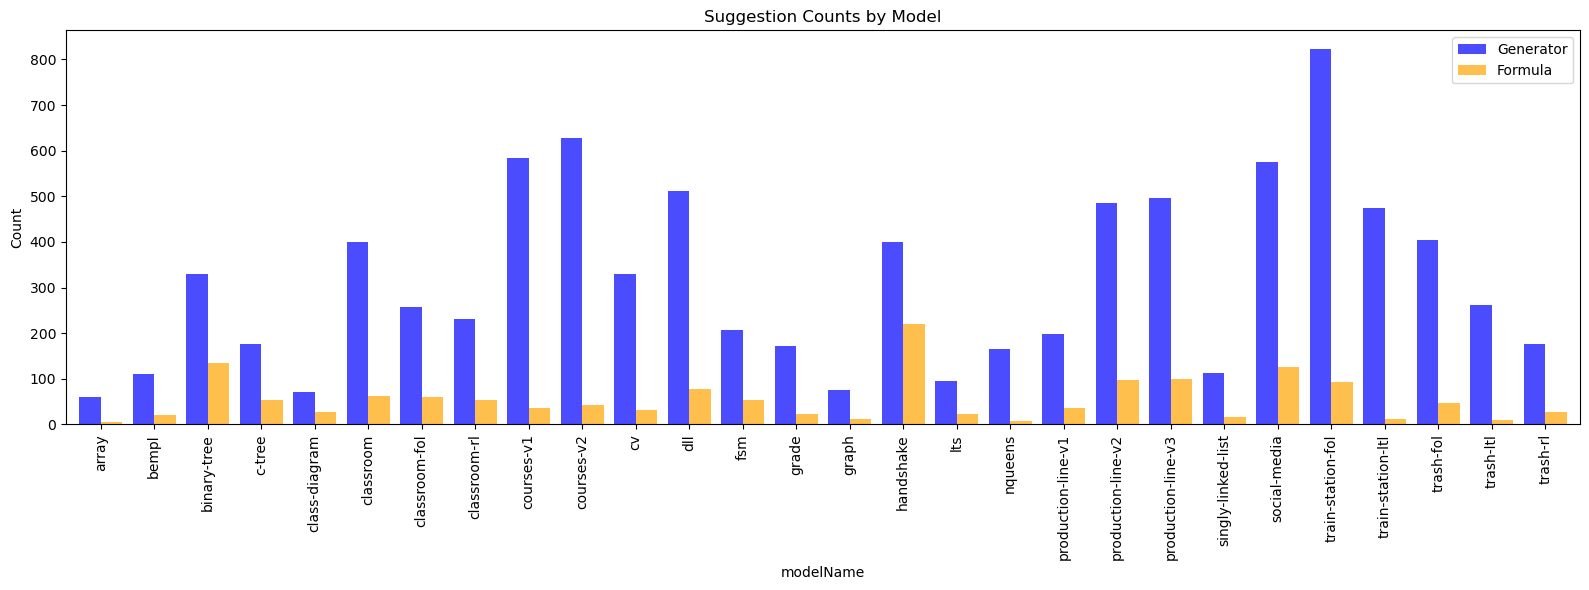

In [11]:
# Create 4 separate charts for better visibility
# Configure matplotlib for better notebook display
plt.rcParams['figure.max_open_warning'] = 0
plt.rcParams['figure.figsize'] = [16, 6]  # Set default figure size
plt.rcParams['figure.dpi'] = 100

# Chart 1: Average Time Comparison
fig, ax = plt.subplots(figsize=(16, 6))
avg_time_combined = pd.DataFrame({
    'Generator': generator_avg_time_per_model,
    'Formula': formula_avg_time_per_model
})
avg_time_combined.plot.bar(ax=ax, title='Average Time (ms)', color=['blue', 'orange'], alpha=0.7, width=0.8)
ax.set_ylabel('Time (ms)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# Chart 3: P99 Time Comparison
fig, ax = plt.subplots(figsize=(16, 6))
p99_time_combined = pd.DataFrame({
    'Generator': generator_p99_time_per_model,
    'Formula': formula_p99_time_per_model
})
p99_time_combined.plot.bar(ax=ax, title='P99 Time (ms)', color=['blue', 'orange'], alpha=0.7, width=0.8)
ax.set_ylabel('Time (ms)')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

# Chart 4: Combined Suggestion Counts as Stacked Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Generator stacked bar chart
generator_suggestion_state_count_per_model.plot.bar(
    ax=axes[0], 
    stacked=True, 
    title='Generator - Suggestion Counts by Model',
    color=['red', 'green', 'gray'],
    alpha=0.7,
    width=0.8
)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Suggestion State', labels=['False', 'True', 'No Suggestion'])

# Formula stacked bar chart
formula_suggestion_state_count_per_model.plot.bar(
    ax=axes[1], 
    stacked=True, 
    title='Formula - Suggestion State Counts by Model',
    color=['red', 'green', 'gray'],
    alpha=0.7,
    width=0.8
)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Suggestion State', labels=['False', 'True', 'No Suggestion'])

plt.tight_layout()
plt.show()

# Chart 5: Suggestion Counts by Model
suggestion_counts_combined = pd.DataFrame({
    'Generator': generator_suggestion_count_per_model,
    'Formula': formula_suggestion_count_per_model
})
suggestion_counts_combined = suggestion_counts_combined.fillna(0)  # Fill NaN values with 0 for better plotting 
# Plotting suggestion counts for Generator and Formula
plt.figure(figsize=(16, 6))
suggestion_counts_combined.plot.bar(
    title='Suggestion Counts by Model',
    color=['blue', 'orange'],
    alpha=0.7,
    width=0.8
)
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

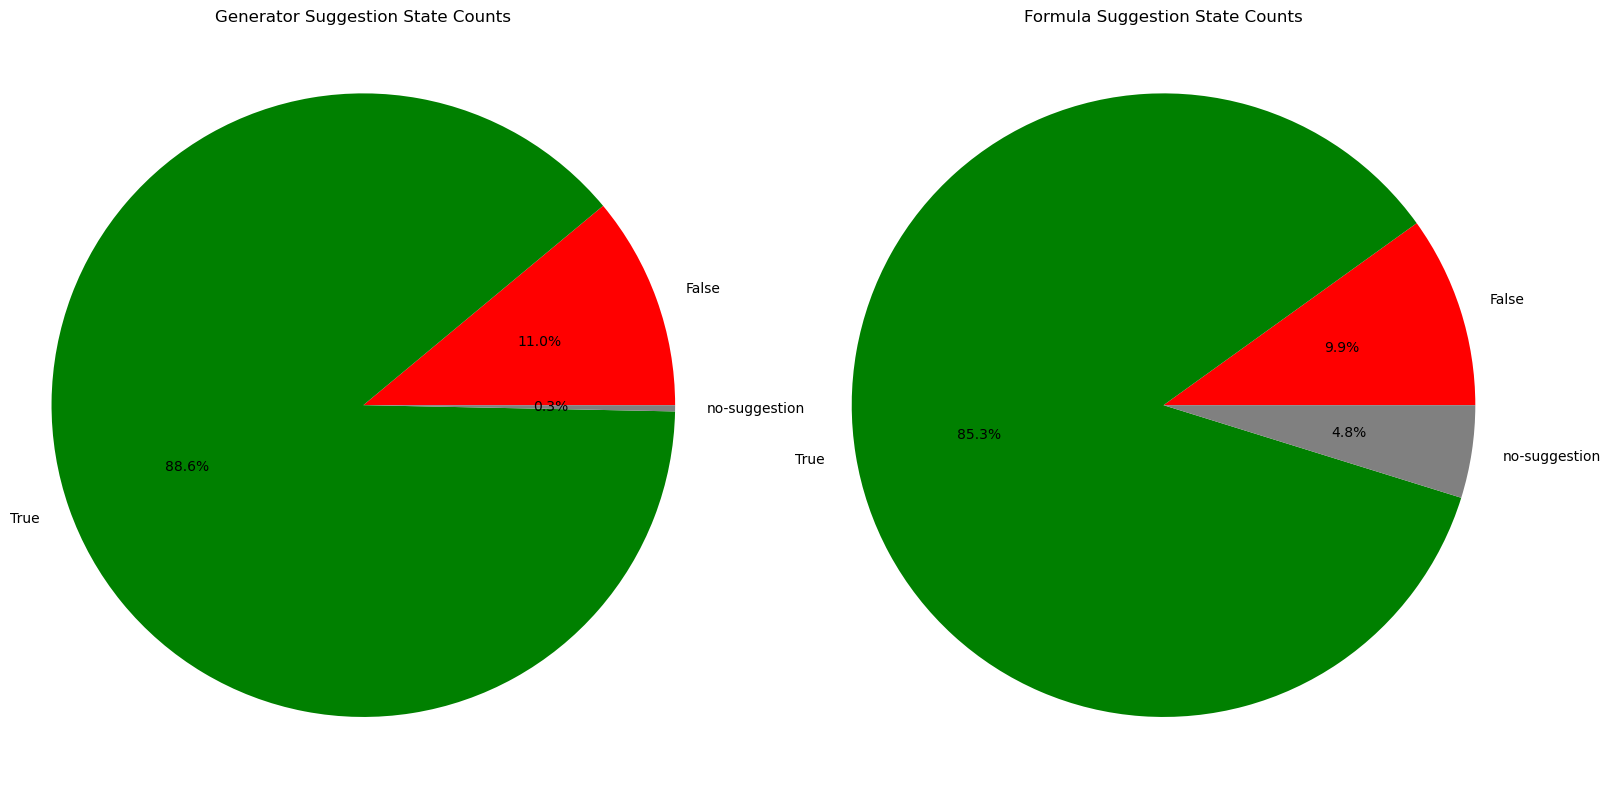

In [12]:
# Pie charts: Generator vs Formula Suggestion State Counts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Generator pie chart
generator_suggestion_state_count.plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    colors=['red', 'green', 'gray'],
    legend=False,
    title='Generator Suggestion State Counts'
)
axes[0].set_ylabel('')
axes[0].set_title('Generator Suggestion State Counts')
axes[0].axis('equal')

# Formula pie chart
formula_suggestion_state_count.plot.pie(
    ax=axes[1],
    autopct='%1.1f%%',
    colors=['red', 'green', 'gray'],
    legend=False,
    title='Formula Suggestion State Counts'
)
axes[1].set_ylabel('')
axes[1].set_title('Formula Suggestion State Counts')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

In [13]:
# Let's examine the suggestion count data to understand the success rates better
print("Generator suggestion counts per model:")
print(generator_suggestion_state_count_per_model)
print("\nFormula suggestion counts per model:")
print(formula_suggestion_state_count_per_model)

# Let's also check the actual suggestion_state values
print("\nGenerator suggestion states:")
print(generator_results_df['suggestion_state'].value_counts())
print("\nFormula suggestion states:")
print(formula_results_df['suggestion_state'].value_counts())

Generator suggestion counts per model:
suggestion_state    False  True  no-suggestion
modelName                                     
array                 0.0   9.0            0.0
bempl                 0.0   8.0            0.0
binary-tree           2.0   7.0            0.0
c-tree                3.0   6.0            0.0
class-diagram         2.0   4.0            0.0
classroom             3.0  27.0            0.0
classroom-fol         4.0  34.0            0.0
classroom-rl          2.0  28.0            0.0
courses-v1            7.0  48.0            0.0
courses-v2           10.0  57.0            0.0
cv                    4.0  20.0            0.0
dll                   1.0   8.0            0.0
fsm                   3.0  12.0            0.0
grade                 0.0  10.0            0.0
graph                 5.0   3.0            0.0
handshake             0.0  20.0            0.0
lts                   4.0  12.0            2.0
nqueens               0.0  16.0            0.0
production-line-v1   

In [14]:
# Join generator and formula results based on modelName and offset
# We'll use a suffix to distinguish columns from each DataFrame

joined_results_df = pd.merge(
    generator_results_df,
    formula_results_df,
    on=['modelName', 'offset', 'filename', 'term', 'line', 'character', 'incompletionLine'],
    how='inner',  # Use inner join to only keep records that exist in both
    suffixes=('_generator', '_formula') 
).sort_values('offset').reset_index(drop=True)

joined_results_df.sample(10)

,modelName,filename,offset,term,line,character,incompletionLine,completionList_generator,completionGenerated_generator,suggestionExists_generator,...,suggestionExists_formula,expectedCompletionWord_formula,expectedCompletionLine_formula,elapsedTimeInMs_formula,evaluationResult_count_formula,evaluationResult_exact_matches_formula,evaluationResult_syntactic_matches_formula,evaluationResult_semantic_matches_formula,evaluationResult_semantic_match_count_formula,suggestion_state_formula
45,production-line-v2,completion/production-line-v2-sig.als,143,extends,7,25,"sig Human, Robot extends","((*parts)-parts), ((*parts).Dangerous), ((*suc...",True,True,...,True,Worker,Worker {},12.977500,12,True,True,False,0,True
491,production-line-v3,completion/production-line-v3-complete.als,1346,.,60,40,all c: Component & Dangerous| all x: c.,"((*parts)-parts), ((*parts).Dangerous), ((*suc...",True,True,...,True,workstation,workstation| no (x.workers & Human),4.062750,38,True,False,False,0,True
378,classroom-rl,completion/classroom-rl-complete.als,865,.,69,39,"all p : Person, c : Class | some p.(c.","((*Tutors)-Tutors), ((*Tutors).p), ((*Tutors)....",True,True,...,True,Groups,Groups) implies Teaches.c in Tutors.p,115.774875,46,True,False,False,0,True
439,classroom-fol,completion/classroom-fol-complete.als,1032,.,69,43,"all c: Class, p: Person | p in (c.Groups).","((*Tutors)-Tutors), ((*Tutors).p), ((*Tutors)....",True,True,...,True,Group,Group implies Teaches.c -> p in Tutors,87.437167,9,True,False,True,8,True
343,train-station-ltl,completion/train-station-ltl-complete.als,750,.,37,51,all t : Track | no prox.t & Junction implies n...,"((*prox)-prox), ((*prox).Entry), ((*prox).Exit...",True,True,...,False,signal,signal,1011.544209,0,False,False,False,0,no-suggestion
151,c-tree,completion/ctree-complete.als,338,in,20,27,"all n1, n2: Node | n1 in","((*neighbors)-neighbors), ((*neighbors).color)...",True,True,...,True,n2,n2.neighbors implies n1 not in n2.^(neighbors-...,386.732500,179,True,False,True,179,True
43,classroom,completion/classroom-sig.als,143,->,10,21,Groups : Person ->,"((*Tutors)-Tutors), ((*Tutors).Student), ((*Tu...",True,True,...,True,Group,Group,17.124375,9,True,True,False,0,True
327,fsm,completion/fsm.als,702,in,40,22,all n: State | n in,"((*transition)-transition), ((*transition).n),...",True,True,...,True,FSM,FSM.start.*transition,367.250583,195,True,False,True,177,True
338,cv,completion/cv-complete.als,744,.,31,52,"all u : User, disj x,y : u.visible | x not in y.","((ids.Id)-x), ((ids.Id)-y), ((ids.Id).ids), ((...",True,False,...,False,^,^(ids.~ids),414.491458,19,False,False,False,0,False
368,fsm,completion/fsm.als,827,in,45,29,all n: State | FSM.stop in,"((*transition)-transition), ((*transition).n),...",True,True,...,True,n,n.*transition,237.745625,194,True,False,True,139,True


In [15]:
joined_results_df.columns

Index(['modelName', 'filename', 'offset', 'term', 'line', 'character',
       'incompletionLine', 'completionList_generator',
       'completionGenerated_generator', 'suggestionExists_generator',
       'expectedCompletionWord_generator', 'expectedCompletionLine_generator',
       'elapsedTimeInMs_generator', 'evaluationResult_count_generator',
       'evaluationResult_exact_matches_generator',
       'evaluationResult_syntactic_matches_generator',
       'evaluationResult_semantic_matches_generator',
       'evaluationResult_semantic_match_count_generator',
       'suggestion_state_generator', 'completionList_formula',
       'completionGenerated_formula', 'suggestionExists_formula',
       'expectedCompletionWord_formula', 'expectedCompletionLine_formula',
       'elapsedTimeInMs_formula', 'evaluationResult_count_formula',
       'evaluationResult_exact_matches_formula',
       'evaluationResult_syntactic_matches_formula',
       'evaluationResult_semantic_matches_formula',
       'e

In [16]:
report_df_alt = joined_results_df.groupby(['modelName']).size().reset_index(name='# loc')

# Column Group: fail to generate suggestion
# no_suggestion_generated_df = joined_results_df[(joined_results_df['completionGenerated_generator'] == False) | (joined_results_df['completionGenerated_formula'] == False)]
# no_suggestion_generated_alt = no_suggestion_generated_df[['modelName', 'completionGenerated_generator', 'completionGenerated_formula']].groupby('modelName').sum().reset_index()

# print(no_suggestion_generated_alt)

# report_df_alt = report_df_alt.merge(no_suggestion_generated_alt, on='modelName', how='left')

# Fill NaN values with 0 for counts
# report_df_alt = report_df_alt.fillna(0)

# FAILURE_TO_GENERATE_COLUMN = '# Failure to Generate?'
# report_df_alt = report_df_alt.rename(columns={
#     'completionFailed_generator': (FAILURE_TO_GENERATE_COLUMN, 'Generator'),
#     'completionFailed_formula': (FAILURE_TO_GENERATE_COLUMN, 'Formula')
# })

# Column Group: total number of suggestions generated
total_suggestions_generated_alt = joined_results_df[['modelName', 'evaluationResult_count_generator','evaluationResult_count_formula',]].groupby('modelName').sum().reset_index()
total_suggestions_generated_alt['diff_total_suggestions'] = (total_suggestions_generated_alt['evaluationResult_count_generator'] - total_suggestions_generated_alt['evaluationResult_count_formula']) / total_suggestions_generated_alt['evaluationResult_count_generator'].replace(0, np.nan) * 100

TOTAL_SUGGESTIONS_GENERATED_COLUMN = '# Total Suggestions Generated'
report_df_alt = report_df_alt.merge(total_suggestions_generated_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values after each merge
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_count_generator': (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Generator'),
    'evaluationResult_count_formula': (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Formula'),
    'diff_total_suggestions': (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Reduction %')
})

# Column Group: Average number of suggestions over location
total_suggestions_generated_alt['avg_suggestion_per_loc_generator'] = total_suggestions_generated_alt['evaluationResult_count_generator'] / report_df_alt['# loc'].replace(0, np.nan)
total_suggestions_generated_alt['avg_suggestion_per_loc_formula'] = total_suggestions_generated_alt['evaluationResult_count_formula'] / report_df_alt['# loc'].replace(0, np.nan)
total_suggestions_generated_alt['diff_avg_suggestions'] = (total_suggestions_generated_alt['avg_suggestion_per_loc_generator'] - total_suggestions_generated_alt['avg_suggestion_per_loc_formula']) / total_suggestions_generated_alt['avg_suggestion_per_loc_generator'].replace(0, np.nan) * 100

avg_suggestion_per_location = total_suggestions_generated_alt[['modelName', 'avg_suggestion_per_loc_generator', 'avg_suggestion_per_loc_formula', 'diff_avg_suggestions']]

AVG_SUGGESTIONS_PER_LOC_COLUMN = 'Avg Suggestions per loc'
report_df_alt = report_df_alt.merge(avg_suggestion_per_location, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values after each merge
report_df_alt = report_df_alt.rename(columns={
    'avg_suggestion_per_loc_generator': (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Generator'),
    'avg_suggestion_per_loc_formula': (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Formula'),
    'diff_avg_suggestions': (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Reduction %')
})

# Column Group: Average time taken
avg_time_taken_alt = joined_results_df[['modelName', 'elapsedTimeInMs_generator', 'elapsedTimeInMs_formula']].groupby('modelName').mean().reset_index()
avg_time_taken_alt['diff_in_mean_time'] = (avg_time_taken_alt['elapsedTimeInMs_generator'] - avg_time_taken_alt['elapsedTimeInMs_formula'])
AVG_TIME_TAKEN_COLUMN = 'Avg Time Taken (ms)'
report_df_alt = report_df_alt.merge(avg_time_taken_alt, on='modelName', how='left')
# Note: Don't fill NaN for time averages as 0 would be misleading
report_df_alt = report_df_alt.rename(columns={
    'elapsedTimeInMs_generator': (AVG_TIME_TAKEN_COLUMN, 'Generator'),
    'elapsedTimeInMs_formula': (AVG_TIME_TAKEN_COLUMN, 'Formula'),
    'diff_in_mean_time': (AVG_TIME_TAKEN_COLUMN, 'Reduction')
})

# Column Group: Count of exact matches
count_of_exact_matches_alt = joined_results_df[['modelName', 'evaluationResult_exact_matches_generator', 'evaluationResult_exact_matches_formula']].groupby('modelName').sum().reset_index()

COUNT_OF_EXACT_MATCHES_COLUMN = '# Exact Matches'
report_df_alt = report_df_alt.merge(count_of_exact_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_exact_matches_generator': (COUNT_OF_EXACT_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_exact_matches_formula': (COUNT_OF_EXACT_MATCHES_COLUMN, 'Formula')
})

# Column Group: Syntactic matches
count_of_syntactic_matches_alt = joined_results_df[['modelName', 'evaluationResult_syntactic_matches_generator', 'evaluationResult_syntactic_matches_formula']].groupby('modelName').sum().reset_index()
report_df_alt = report_df_alt.merge(count_of_syntactic_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
COUNT_OF_SYNTACTIC_MATCHES_COLUMN = '# Syntactic Matches'
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_syntactic_matches_generator': (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_syntactic_matches_formula': (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Formula')
})

# Column Group: Semantic matches
# Note: This part is not included in the original code, but if needed, it can be added similarly
count_of_semantic_matches_alt = joined_results_df[['modelName', 'evaluationResult_semantic_matches_generator', 'evaluationResult_semantic_matches_formula']].groupby('modelName').sum().reset_index()
report_df_alt = report_df_alt.merge(count_of_semantic_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
COUNT_OF_SEMANTIC_MATCHES_COLUMN = '# Loc with Semantic Matches'
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_semantic_matches_generator': (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_semantic_matches_formula': (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Formula')
})

# Column Group: Total Semantic Matches
count_of_total_semantic_matches_alt = joined_results_df[['modelName', 'evaluationResult_semantic_match_count_generator', 'evaluationResult_semantic_match_count_formula']].groupby('modelName').sum().reset_index()
report_df_alt = report_df_alt.merge(count_of_total_semantic_matches_alt, on='modelName', how='left')
report_df_alt = report_df_alt.fillna(0)  # Fill NaN values for counts
COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN = '# Total Semantic Matches'
report_df_alt = report_df_alt.rename(columns={
    'evaluationResult_semantic_match_count_generator': (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    'evaluationResult_semantic_match_count_formula': (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Formula')
})

# Create the multi-level column index
report_df_alt.columns = pd.MultiIndex.from_tuples([
    ('', 'modelName'),
    ('', '# loc'),
    # (FAILURE_TO_GENERATE_COLUMN, 'Generator'),
    # (FAILURE_TO_GENERATE_COLUMN, 'Formula'),
    (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Generator'),
    (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Formula'),
    (TOTAL_SUGGESTIONS_GENERATED_COLUMN, 'Reduction %'),

    (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Generator'),
    (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Formula'),
    (AVG_SUGGESTIONS_PER_LOC_COLUMN, 'Reduction %'),

    (AVG_TIME_TAKEN_COLUMN, 'Generator'),
    (AVG_TIME_TAKEN_COLUMN, 'Formula'),
    (AVG_TIME_TAKEN_COLUMN, 'Reduction'),

    (COUNT_OF_EXACT_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_EXACT_MATCHES_COLUMN, 'Formula'),
    (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_SYNTACTIC_MATCHES_COLUMN, 'Formula'),
    (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_SEMANTIC_MATCHES_COLUMN, 'Formula'),
    (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Generator'),
    (COUNT_OF_TOTAL_SEMANTIC_MATCHES_COLUMN, 'Formula')
])

# Final cleanup: Fill any remaining NaN values
# For count columns, use 0; for time columns, keep NaN (as 0 would be misleading)
numeric_cols = report_df_alt.select_dtypes(include=[np.number]).columns
count_cols = [col for col in numeric_cols if 'time' not in str(col).lower()]

# Apply fillna(0) only to count columns, not time columns
for col in count_cols:
    if col != ('', '# loc'):  # Don't fill the location count as it should always have values
        report_df_alt[col] = report_df_alt[col].fillna(0)

# Format all floating point numbers to 2 decimal places (except for integer columns)
for col in report_df_alt.columns:
    if pd.api.types.is_float_dtype(report_df_alt[col]):
        report_df_alt[col] = report_df_alt[col].round(2)

report_df_alt

# Total Suggestions Generated          \
             modelName # loc                     Generator Formula   
0                array     9                           546      54   
1                bempl     8                           887     160   
2          binary-tree     9                          2970    1212   
3               c-tree     9                          1589     488   
4        class-diagram     6                           425     170   
5            classroom    30                         11988    1880   
6        classroom-fol    38                          9821    2301   
7         classroom-rl    30                          6907    1580   
8           courses-v1    55                         32116    1994   
9           courses-v2    67                         42101    2794   
10                  cv    24                          7923     743   
11                 dll     9                          4614     708   
12                 fsm    15                          3096     790   
13               grade    10                          1710     219   
14               graph     8                           602      91   
15           handshake    20                          7989    4392   
16                 lts    18                          1721     406   
17             nqueens    16                          2632     128   
18  production-line-v1    12                          2383     443   
19  production-line-v2    34                         16474    3324   
20  production-line-v3    36                         17848    3549   
21  singly-linked-list     4                           455      67   
22        social-media    33                         18976    4121   
23   train-station-fol    26                         21390    2440   
24   train-station-ltl    46                         21805     519   
25           trash-fol    18                          7287     835   
26           trash-ltl    23                          6046     214   
27            trash-rl    12                          2112     329   

               Avg Suggestions per loc                      \
   Reduction %               Generator Formula Reduction %   
0        90.11                   60.67    6.00       90.11   
1        81.96                  110.88   20.00       81.96   
2        59.19                  330.00  134.67       59.19   
3        69.29                  176.56   54.22       69.29   
4        60.00                   70.83   28.33       60.00   
5        84.32                  399.60   62.67       84.32   
6        76.57                  258.45   60.55       76.57   
7        77.12                  230.23   52.67       77.12   
8        93.79                  583.93   36.25       93.79   
9        93.36                  628.37   41.70       93.36   
10       90.62                  330.12   30.96       90.62   
11       84.66                  512.67   78.67       84.66   
12       74.48                  206.40   52.67       74.48   
13       87.19                  171.00   21.90       87.19   
14       84.88                   75.25   11.38       84.88   
15       45.02                  399.45  219.60       45.02   
16       76.41                   95.61   22.56       76.41   
17       95.14                  164.50    8.00       95.14   
18       81.41                  198.58   36.92       81.41   
19       79.82                  484.53   97.76       79.82   
20       80.12                  495.78   98.58       80.12   
21       85.27                  113.75   16.75       85.27   
22       78.28                  575.03  124.88       78.28   
23       88.59                  822.69   93.85       88.59   
24       97.62                  474.02   11.28       97.62   
25       88.54                  404.83   46.39       88.54   
26       96.46                  262.87    9.30       96.46   
27       84.42                  176.00   27.42       84.42   

   Avg Time Taken (ms)                   # Exact Matches          \

In [17]:
report_df_alt.to_csv('completion_performance.tsv', index=False, sep='\t')